In [1]:
import numpy as np
import matplotlib.pyplot as plt
import flamedisx as fd
import pickle as pkl
import sys
from copy import deepcopy
sys.path.append('../')
from create_simple_template_likelihood import BasicTemplateSource

2025-12-01 04:41:05.031841: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764592865.166261 1032231 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764592865.173397 1032231 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764592865.697351 1032231 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764592865.697409 1032231 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764592865.697412 1032231 computation_placer.cc:177] computation placer alr

In [2]:
with open('/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/likelihoods/3D_neutrons_0.1_LNGS.pkl', 'rb') as f:
    likelihood_container = pkl.load(f)

print(likelihood_container.expected_background_counts)
print(likelihood_container.gaussian_constraint_widths)

{'SolarER': 11.718320740830983, 'Pb214': 2.262939732733155, 'Kr85': 10.324151095361335, 'Xe136': 3.8772032258544913, 'Xe124': 1.1607123429016117, 'Neutrons': 0.004620238857386561, 'CEvNS_other': 0.04620238857386554, 'CEvNS_solar': 1.175978297781372}
{'SolarER': 0.5437300823745576, 'Pb214': 0.3779109353664369, 'Kr85': 1.7241332329253432, 'Xe136': 0.5815804838781736, 'Xe124': 0.23214246858032236, 'Neutrons': 0.0009240477714773122, 'CEvNS_other': 0.009009465771903782, 'CEvNS_solar': 0.046686338421920465}


In [3]:
likelihood_container.__dict__.keys()

dict_keys(['sources', 'arguments', 'batch_size', 'log_constraint', 'expected_signal_counts', 'expected_background_counts', 'gaussian_constraint_widths', 'signal_counts_uncertainties'])

In [4]:
likelihood_container.sources

{'SolarER': create_simple_template_likelihood.BasicTemplateSource,
 'Pb214': create_simple_template_likelihood.BasicTemplateSource,
 'Kr85': create_simple_template_likelihood.BasicTemplateSource,
 'Xe136': create_simple_template_likelihood.BasicTemplateSource,
 'Xe124': create_simple_template_likelihood.BasicTemplateSource,
 'Neutrons': create_simple_template_likelihood.BasicTemplateSource,
 'CEvNS_other': create_simple_template_likelihood.BasicTemplateSource,
 'CEvNS_solar': create_simple_template_likelihood.BasicTemplateSource,
 'WIMP': create_simple_template_likelihood.BasicTemplateSource}

In [5]:
likelihood_container.arguments

{'SolarER': {'template': <multihist.Histdd at 0x7f0ac01d9790>},
 'Pb214': {'template': <multihist.Histdd at 0x7f090659e710>},
 'Kr85': {'template': <multihist.Histdd at 0x7f0905f95e90>},
 'Xe136': {'template': <multihist.Histdd at 0x7f09063dd0d0>},
 'Xe124': {'template': <multihist.Histdd at 0x7f0905ed1650>},
 'Neutrons': {'template': <multihist.Histdd at 0x7f0ac01d1210>},
 'CEvNS_other': {'template': <multihist.Histdd at 0x7f0ac01d2f50>},
 'CEvNS_solar': {'template': <multihist.Histdd at 0x7f0ac01d3f90>},
 'WIMP': {'template': <multihist.Histdd at 0x7f0ac01d3150>}}

Next, we open the inference config in the way it is used in asymptotic_inference.py to produce the log likelihood.

In [6]:
import configparser

config = configparser.ConfigParser(allow_no_value=True)
config.optionxform = str
with open("/global/cfs/cdirs/lz/users/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/inference_configs/disco_study_neutrons.ini", encoding="utf-8-sig") as f:
    config.read_file(f)


background_sources = list(config["background_sources"].keys())
signal_sources = list(config["signal_sources"].keys())
ntoys = int(config["inference_parameters"]["ntoys"])


background_source_names = background_sources
signal_source_names = signal_sources
print(background_source_names)
print(signal_source_names)

FileNotFoundError: [Errno 2] No such file or directory: '/global/cfs/cdirs/lz/users/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/inference_configs/disco_study_neutrons.ini'

Producing the log likelihood.

In [ ]:
sources = dict()
arguments = dict()
for sname, source in likelihood_container.sources.items():
    if (sname == signal_source_names) or (sname in background_source_names):
        sources[sname] = source
        arguments[sname] = likelihood_container.arguments[sname]

print(arguments)
print(sources)

likelihood = fd.LogLikelihood(sources=sources,
                                        arguments=arguments,
                                        batch_size=likelihood_container.batch_size,
                                        free_rates=tuple(sources.keys()),
                                        log_constraint=likelihood_container.log_constraint)


simulated_data = likelihood.simulate(fix_truth=None)
print(simulated_data)
print(np.shape(simulated_data))
print(type(simulated_data))

/global/cfs/cdirs/lz/users/rory_m/.conda/envs/flamedisx/lib/python3.11/site-packages/flamedisx/source.py:271: UserWarning: Defaults for unused settings ignored: {'max_sigma': None, 'max_sigma_outer': None}
  warnings.warn(f"Defaults for unused settings ignored: {unused}")


{'SolarER': {'template': <multihist.Histdd object at 0x7f07f52c7ed0>}, 'Pb214': {'template': <multihist.Histdd object at 0x7f0997f70050>}, 'Kr85': {'template': <multihist.Histdd object at 0x7f07f510e650>}, 'Xe136': {'template': <multihist.Histdd object at 0x7f07f4a74050>}, 'Xe124': {'template': <multihist.Histdd object at 0x7f07e02f1b90>}, 'Neutrons': {'template': <multihist.Histdd object at 0x7f07e00fc310>}, 'CEvNS_other': {'template': <multihist.Histdd object at 0x7f07e00fc710>}, 'CEvNS_solar': {'template': <multihist.Histdd object at 0x7f07e00fca50>}}
{'SolarER': <class 'create_simple_template_likelihood.BasicTemplateSource'>, 'Pb214': <class 'create_simple_template_likelihood.BasicTemplateSource'>, 'Kr85': <class 'create_simple_template_likelihood.BasicTemplateSource'>, 'Xe136': <class 'create_simple_template_likelihood.BasicTemplateSource'>, 'Xe124': <class 'create_simple_template_likelihood.BasicTemplateSource'>, 'Neutrons': <class 'create_simple_template_likelihood.BasicTemplate

Estimating mus: 0it [00:00, ?it/s]
Estimating mus: 0it [00:00, ?it/s]
Estimating mus: 0it [00:00, ?it/s]
Estimating mus: 0it [00:00, ?it/s]
Estimating mus: 0it [00:00, ?it/s]
Estimating mus: 0it [00:00, ?it/s]
Estimating mus: 0it [00:00, ?it/s]
Estimating mus: 0it [00:00, ?it/s]

         cS1  log10_cS2        radius       source
0  23.409756   3.748748  20090.894309        Pb214
1  82.259252   3.882629  16051.900900  CEvNS_other
2  35.076146   3.961220   1781.470274        Xe136
3  14.740271   3.543197  20350.583537     Neutrons
4  44.544992   3.961776   4871.691667        Pb214
5   4.111637   2.654031  14700.761831  CEvNS_solar
(6, 4)
<class 'pandas.core.frame.DataFrame'>


In [ ]:
#removing the 'source' column and using set_data()
df = simulated_data.iloc[:, :-1]
print(df)
print(np.shape(df))
likelihood.set_data(df)


         cS1  log10_cS2        radius
0  23.409756   3.748748  20090.894309
1  82.259252   3.882629  16051.900900
2  35.076146   3.961220   1781.470274
3  14.740271   3.543197  20350.583537
4  44.544992   3.961776   4871.691667
5   4.111637   2.654031  14700.761831
(6, 3)


Finding the value of the mu estimators.

In [ ]:
for sname, mu in likelihood.mu_estimators.items():
 print(sname, mu())

SolarER tf.Tensor(1.0, shape=(), dtype=float32)
Pb214 tf.Tensor(1.0, shape=(), dtype=float32)
Kr85 tf.Tensor(1.0, shape=(), dtype=float32)
Xe136 tf.Tensor(1.0, shape=(), dtype=float32)
Xe124 tf.Tensor(1.0, shape=(), dtype=float32)
Neutrons tf.Tensor(1.0, shape=(), dtype=float32)
CEvNS_other tf.Tensor(1.0, shape=(), dtype=float32)
CEvNS_solar tf.Tensor(1.0, shape=(), dtype=float32)


Our mu_estimators are equal to 1, so our expected no. of counts are equal to the rate multiplier.

In [ ]:
import scipy.stats as stats
from tqdm import tqdm

means, sigmas, param_names = [], [], []

expected_background_counts = likelihood_container.expected_background_counts
gaussian_constraint_widths = likelihood_container.gaussian_constraint_widths
sources_remove = []
fix_dict = {}

#Applying a constraint on out likelihood

constraint_extra_args = dict()
for background_source, counts in expected_background_counts.items():
    constraint_extra_args[f'{background_source}_expected_counts'] = counts

likelihood.set_constraint_extra_args(**constraint_extra_args)



for k,v in expected_background_counts.items():
    
    if k in sources_remove:
        continue
    if k not in gaussian_constraint_widths:
        print(k)
        continue
    
    means.append(v)
    sigmas.append(gaussian_constraint_widths[k])

    param_names.append(k+'_rate_multiplier')
means = np.array(means)
sigmas = np.array(sigmas)
print(param_names)
nuisance_param_sampler = stats.multivariate_normal(mean=means, cov=np.diag(np.square(sigmas)), allow_singular=True) #sampling nuissance parameters from our likelihood container values. One distribtuion per source.


def get_pulls(toys=500):
    pulls = {k: [] for k in param_names}    #creating empty sets for each source in param_names
    MLEs = {k: [] for k in param_names}
    stds = {k: [] for k in param_names}
    true = {k: [] for k in param_names}
    this_likelihood = deepcopy(likelihood)  #deepcopy creates a copy of the likelihood without changing the original likelihood
    chi2_values = [] 
    ll_values = []
    for i in tqdm(range(toys)):
        sample = nuisance_param_sampler.rvs()   #generates a random sample from the gaussian distributions
        toy_simulate_dict = dict()
        for j, name in enumerate(param_names):
            if sample[j] < 0:
                sample[j] = 0.0
            toy_simulate_dict[name] = sample[j]


        # Generate toy data
        toy_data = this_likelihood.simulate(**toy_simulate_dict) #(**toy_simlate_dict) is of the form (<source1> = 1.23587, <source2> = 6.0925) etc.
        toy_data = toy_data.iloc[:, :-1] #removing the source name column from our simulated dataset
        this_likelihood.set_data(toy_data)


        # try:

        bestfit = this_likelihood.bestfit(guess=toy_simulate_dict, fix=fix_dict)        #returns the best fit for each source

        # except:                                                                             #Getting rid of the case where the best fit doesn't work
        #     bestfit = {k:np.nan for k in this_likelihood.param_defaults.keys()}
        #     print(bestfit)
        # Get the uncertainties
        cov = 2. * this_likelihood.inverse_hessian(bestfit, omit_grads=tuple(fix_dict.keys())) #the covariance matrix of the maximum likelihood estimator
        list_std_errs = np.diag(cov) ** 0.5
        corr = cov * np.outer(1 / list_std_errs, 1 / list_std_errs)
        std_errs = dict()
        for i, name in enumerate(bestfit):
            if name in fix_dict:
                continue
            std_errs[name] = list_std_errs[i]
        
        for component in bestfit.keys():
            if component not in pulls:
                continue
            pulls[component].append((bestfit[component] - toy_simulate_dict[component]) / std_errs[component])
            MLEs[component].append(bestfit[component])
            stds[component].append(std_errs[component])
            true[component].append(toy_simulate_dict[component])
    return pulls,MLEs,stds,true

['SolarER_rate_multiplier', 'Pb214_rate_multiplier', 'Kr85_rate_multiplier', 'Xe136_rate_multiplier', 'Xe124_rate_multiplier', 'Neutrons_rate_multiplier', 'CEvNS_other_rate_multiplier', 'CEvNS_solar_rate_multiplier']


In [ ]:
pulls, MLEs, stds, true = get_pulls()

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [01:36<00:00,  5.16it/s]


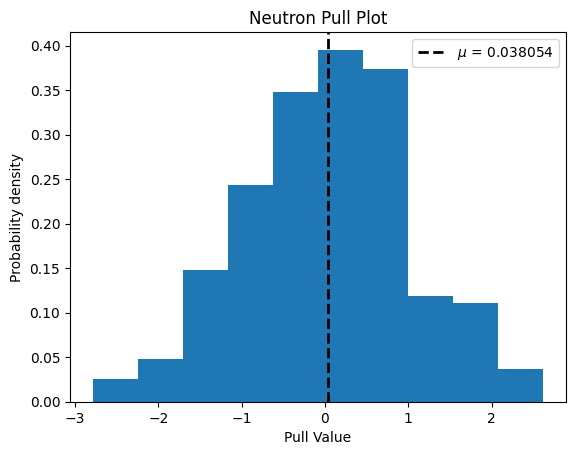

In [ ]:
#print(pulls['Neutrons_rate_multiplier'])
mean_neutrons = np.mean(pulls['Neutrons_rate_multiplier'])
plt.hist(pulls['Neutrons_rate_multiplier'], density=true)
plt.title('Neutron Pull Plot')
plt.ylabel('Probability density')
plt.xlabel('Pull Value')
plt.axvline(x=mean_neutrons, color='k', linestyle='--', linewidth=2, label=f'$\mu$ = {mean_neutrons:2f}')
plt.legend()
plt.show()

In [ ]:
mean_neutrons = np.mean(MLEs['Neutrons_rate_multiplier'])
print(mean_neutrons)

print(likelihood_container.expected_background_counts['Neutrons'])
print(likelihood_container.gaussian_constraint_widths['Neutrons'])

print(likelihood_container.expected_background_counts['Neutrons']+likelihood_container.gaussian_constraint_widths['Neutrons'])

0.004620777484197291
0.004620238857386561
0.0009240477714773122
0.005544286628863873


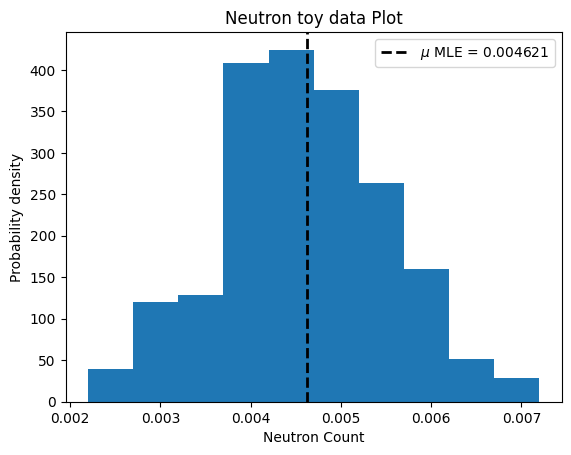

In [ ]:
#print(pulls['Neutrons_rate_multiplier'])
mean_MLE= np.mean(MLEs['Neutrons_rate_multiplier'])
plt.hist(true['Neutrons_rate_multiplier'], density=true)
plt.title('Neutron toy data Plot')
plt.ylabel('Probability density')
plt.xlabel('Neutron Count')
plt.axvline(x=mean_MLE, color='k', linestyle='--', linewidth=2, label=f'$\mu$ MLE = {mean_neutrons:2f}')
plt.legend()
plt.show()

In [ ]:
print(stds['Neutrons_rate_multiplier'])

std_neutrons_ = np.mean(stds['Neutrons_rate_multiplier'])
print(std_neutrons_)